# Calibrate a DakisSX pulse on real IQM hardware

In [3]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from qiskit import QuantumCircuit

from iqm.qiskit_iqm import IQMProvider
from iqm.pulla.pulla import Pulla
from iqm.pulla.utils_qiskit import get_qiskit_compiler
from iqm.pulse.gates.prx import PRX_CustomWaveformsSX
from iqm.pulse.playlist.waveforms import Waveform
from exa.common.control.sweep.sweep import Sweep

import iqm_tools


## Load the pulse

2 file(s) found:

[0]  pulse_fields_SX_40_3points_2.json
[1]  pulse_fields_X_cfg0039.json

File:      pulse_fields_SX_40_3points_2.json
source:    Robust_Results_9_detuning/dakis_detuning_sens_SX_40_3points_2.pkl
gate:      SX (rx(pi/2))
n_points:  4096


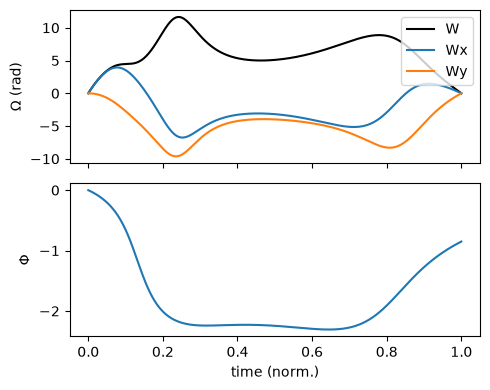

In [4]:
RESULTS_DIR = 'Results/Pulses'

files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json')), key=os.path.getmtime)
print(f'{len(files)} file(s) found:\n')
for i, f in enumerate(files):
    print(f'[{i}]  {os.path.basename(f)}')

idx = 0   # -1 = most recent
with open(files[idx]) as f:
    data = json.load(f)

print(f"\nFile:      {os.path.basename(files[idx])}")
print(f"source:    {data.get('source_pkl', 'N/A')}")
print(f"gate:      {data.get('gate', 'N/A')}")
print(f"n_points:  {data.get('n_points', 'N/A')}")

times = np.array(data['fields']['times'])
omega = np.array(data['fields']['omega'])
phi   = np.array(data['fields']['phi'])

Wx = omega * np.cos(phi)
Wy = omega * np.sin(phi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
ax1.plot(times, omega, 'k', label='W')
ax1.plot(times, Wx, label='Wx')
ax1.plot(times, Wy, label='Wy')
ax1.set_ylabel(r'$\Omega$ (rad)')
ax1.legend()
ax2.plot(times, phi)
ax2.set_ylabel(r'$\Phi$')
ax2.set_xlabel('time (norm.)')
plt.tight_layout()
plt.show()


## Connect to IQM hardware

Everything from here on talks to a live server.


In [ ]:
# IQM_TOKEN must be set as an environment variable before running this notebook.
# Never hardcode a real token in a notebook cell, especially in a public repo.
#   export IQM_TOKEN="<your-api-token-here>"   # set this in your shell, before launching Jupyter
if 'IQM_TOKEN' not in os.environ:
    raise RuntimeError(
        "Set the IQM_TOKEN environment variable before running this notebook "
        "(e.g. `export IQM_TOKEN=<your-api-token-here>` in your shell before launching Jupyter). "
        "Never hardcode a token in a notebook cell, especially in a public repo."
    )

iqm_server_url = 'https://resonance.iqm.tech/emerald'   # <- change to your target machine

pulla = Pulla(iqm_server_url)
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()

print(f'Connected to {iqm_server_url}')


## Live qubit calibration

In [ ]:
expr_params = iqm_tools.get_qubit_params(iqm_server_url)
print('calibration_set_id:', expr_params.attrs['calibration_set_id'])
expr_params


## Match the pulse to a qubit + snap the gate duration to the hardware grid

Compares each live qubit's anharmonicity against the anharmonicity this pulse was
designed for (`design_anharmonicity_Tg_alpha` in the pulse-fields file — the nominal
value; the original notebook refined this further with a private leakage-optimization
sweep not available here, so this match is an approximation) and snaps the implied gate
duration to the nearest 4 ns (the SqrtX hardware grid: 4, 8, 12, ..., 36, 40, 44, ...).


In [ ]:
design_anharm = data.get('design_anharmonicity_Tg_alpha')
if design_anharm is None:
    raise ValueError("This pulse-fields file has no 'design_anharmonicity_Tg_alpha' -- "
                      "set Texp_ns and qbt manually instead of running this cell.")

anharm_GHz = expr_params['anharmonicity_MHz'].values / 1000  # MHz -> GHz
ratio = (design_anharm / (2 * np.pi)) / anharm_GHz

result = expr_params[['qubit']].copy()
result['anharmonicity_GHz'] = anharm_GHz
result['Te_ns'] = ratio

Te_ns = result['Te_ns'].values
Te_snapped = np.maximum(np.round(Te_ns / 4) * 4, 4)
result['Te_snapped'] = Te_snapped
result['dist_to_grid'] = np.abs(Te_ns - Te_snapped)

sorted_result = result.sort_values('dist_to_grid')
print(sorted_result[['qubit', 'Te_ns', 'Te_snapped', 'dist_to_grid']].to_string())


In [ ]:
qq = 0   # index into sorted_result -- 0 = best match

qbt   = sorted_result['qubit'].iloc[qq]
Texp  = sorted_result['Te_snapped'].iloc[qq]

print(f'qubit = {qbt},  Texp = {Texp} ns')


## Discretize the pulse for this qubit's gate duration

Resample onto the hardware's 0.5 ns sample grid and normalize to the
`max(|I|)^2 + max(|Q|)^2 <= 1` constraint.


In [ ]:
Wx_rhz = Wx / Texp   # rad/ns
Wy_rhz = Wy / Texp

N_samples = int(round(Texp / 0.5))
t_grid = np.linspace(0, 1, N_samples, endpoint=False)

Wx_hw = np.interp(t_grid, times, Wx_rhz)
Wy_hw = np.interp(t_grid, times, Wy_rhz)

max_norm = np.sqrt(np.max(np.abs(Wx_hw))**2 + np.max(np.abs(Wy_hw))**2)
i_samples = Wx_hw / max_norm
q_samples = Wy_hw / max_norm

print(f'N_samples = {N_samples},  Texp = {Texp} ns')
print(f'max(|I|)^2 + max(|Q|)^2 = {np.max(np.abs(i_samples))**2 + np.max(np.abs(q_samples))**2:.4f}  (must be <= 1)')

envelope = np.sqrt(i_samples**2 + q_samples**2)
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(envelope, 'k', label='envelope')
ax.plot(i_samples, 'o-', markersize=3, linewidth=0.5, label='I')
ax.plot(q_samples, 'o-', markersize=3, linewidth=0.5, label='Q')
ax.set_ylabel('normalized amplitude')
ax.set_xlabel('sample index')
ax.legend()
plt.tight_layout()
plt.show()


## Define a custom gate from the discretized samples

In [ ]:
_I_SAMPLES = i_samples.copy()
_Q_SAMPLES = q_samples.copy()
_N         = len(_I_SAMPLES)

@dataclass(frozen=True)
class DakisSXWave_I(Waveform):
    def _sample(self, sample_coords: np.ndarray) -> np.ndarray:
        t_grid = np.linspace(0, 1, _N, endpoint=False)
        return np.interp(sample_coords + 0.5, t_grid, _I_SAMPLES,
                         left=_I_SAMPLES[0], right=_I_SAMPLES[-1])

@dataclass(frozen=True)
class DakisSXWave_Q(Waveform):
    def _sample(self, sample_coords: np.ndarray) -> np.ndarray:
        t_grid = np.linspace(0, 1, _N, endpoint=False)
        return np.interp(sample_coords + 0.5, t_grid, _Q_SAMPLES,
                         left=_Q_SAMPLES[0], right=_Q_SAMPLES[-1])

# PRX_CustomWaveformsSX: single SX pulse for theta=pi/2, adds rz_before / rz_after parameters
class DakisSXGate(PRX_CustomWaveformsSX, wave_i=DakisSXWave_I, wave_q=DakisSXWave_Q):
    """Leakage-suppressed sqrt(X) gate with virtual-Z frame correction."""
    pass

print(f'DakisSXGate defined  |  max_i={np.max(np.abs(i_samples)):.5f}  max_q={np.max(np.abs(q_samples)):.5f}')


## Compiler setup

In [ ]:
compiler = get_qiskit_compiler(pulla, backend)
compiler.add_implementation("prx", "dakis_sx", DakisSXGate)

Delta_ghz = 0.0   # LO detuning offset -- refined in the frequency-sweep section below

def get_dakis_sx_settings(circuits):
    s = compiler.get_settings(circuits=circuits)
    s.gate_definitions.prx.default_implementation = "dakis_sx"
    s.gates.prx.dakis_sx[qbt].set_from_dict({
        "duration":    Texp * 1e-9,
        "amplitude_i": amp_sx,
        "amplitude_q": amp_sx,
        "rz_before":   0.0,
        "rz_after":    0.0,
    })
    drive = s.controllers[qbt].drive
    drive.frequency = drive.frequency.value + Delta_ghz * 1e9
    return s

# Calibration circuit: single SX -> P(|1>) ~= 0.5 at correct amplitude
qc = QuantumCircuit(1, 1)
qc.sx(0)
qc.measure(0, 0)
qc.draw('mpl')


## Rabi amplitude calibration (3 rounds)

In [ ]:
def run_rabi_round(amp_center, amp_span, n_points, n_shots):
    A_values = np.clip(np.linspace(amp_center - amp_span, amp_center + amp_span, n_points), 0.0, 1.0)

    s = compiler.get_settings(circuits=[qc])
    s.gate_definitions.prx.default_implementation = "dakis_sx"
    s.gates.prx.dakis_sx[qbt].set_from_dict({
        "duration":    Texp * 1e-9,
        "amplitude_i": amp_center,
        "amplitude_q": amp_center,
        "rz_before":   0.0,
        "rz_after":    0.0,
    })
    drive = s.controllers[qbt].drive
    drive.frequency = drive.frequency.value + Delta_ghz * 1e9
    s.set_shots(n_shots)

    qs = s.gates.prx.dakis_sx[qbt]
    amp_sweep = (
        Sweep(parameter=qs.amplitude_i.parameter, data=A_values),
        Sweep(parameter=qs.amplitude_q.parameter, data=A_values),
    )

    jd, ctx = compiler.compile(circuits=[qc], components=[qbt], settings=s, sweeps=[amp_sweep])
    job = pulla.submit_playlist(jd, context=ctx)
    job.wait_for_completion()

    if job.status != 'completed':
        print(f"Job failed: {job.status}")
        return None, None, None, None, None

    res  = job.result(compiler)
    prob_raw  = res.dataset["counter.result"].values[1]
    prob_corr = res.dataset[f'{qbt}__c_1_0_0_excited_state_probability'].values

    best_idx = np.argmin(np.abs(prob_raw - 0.5))
    best_A   = A_values[best_idx]
    print(f"  -> best A = {best_A:.5f}  (P(raw)={prob_raw[best_idx]:.4f}, P(corr)={prob_corr[best_idx]:.4f}, target=0.5)")
    return res, A_values, prob_raw, prob_corr, best_A


In [ ]:
# ── Round 1: wide scan ──────────────────────────────────────────────────────
# amp_center is a rough starting guess -- adjust based on your qubit/gate duration
# (e.g. check the native SX gate's amplitude in expr_params / prior calibrations as a ballpark).
print("Round 1")
res1, A1, P1, P1_corr, best1 = run_rabi_round(amp_center=0.16,
                                              amp_span  = 0.02,
                                              n_points  = 11,
                                              n_shots   = 500)
plt.plot(A1, P1)


In [ ]:
# ── Round 2: narrow scan around Round 1 peak ───────────────────────────────
print("Round 2")
res2, A2, P2, P2_corr, best2 = run_rabi_round(amp_center=best1,
                                              amp_span = 0.005,
                                              n_points = 11,
                                              n_shots  = 1000)


In [ ]:
# ── Round 3: fine scan around Round 2 peak ─────────────────────────────────
print("Round 3")
res3, A3, P3, P3_corr, best3 = run_rabi_round(amp_center=best2,
                                              amp_span  = 0.001,
                                              n_points  = 15,
                                              n_shots   = 2000)


In [ ]:
amp_sx = best3
print(f"\nFinal sqrt(X) amplitude A = {amp_sx:.5f}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles  = ['Round 1', 'Round 2', 'Round 3']
results = [(A1, P1, P1_corr, best1), (A2, P2, P2_corr, best2), (A3, P3, P3_corr, best3)]

for ax, (A, P, P_corr, best), title in zip(axes, results, titles):
    ax.plot(A, P, 'o-', label='raw')
    ax.plot(A, P_corr, 's-', label='corr')
    ax.axvline(best, color='tab:red', linestyle='--', label=f'A={best:.4f}')
    ax.set_xlabel('amplitude A')
    ax.set_ylabel("P(|1>)  [SX^2 circuit]")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


## Virtual-Z frame calibration (`rz_after`)

In [ ]:
# N SX gates (multiple of 4 -> SX^N=I ends in |0>, so ground-state measurement avoids
# T1/readout bias), sweeping the DakisSXGate implementation's own rz_after Setting
# directly -- applies to every SX in the circuit including the last one, harmless since
# a trailing virtual-Z is a diagonal phase with zero effect on Z-basis population.
# find argmin P(|1>) <-> argmax P(|0>)
rz_n_gates  = 20       # multiple of 4; more gates -> more phase sensitivity
rz_n_points = 51
rz_n_shots  = 1000
rz_vals = np.linspace(-1., 1., rz_n_points)

qc_rz = QuantumCircuit(1, 1)
for _ in range(rz_n_gates):
    qc_rz.sx(0)
    qc_rz.barrier(0)
qc_rz.measure(0, 0)

s = get_dakis_sx_settings([qc_rz])
s.set_shots(rz_n_shots)

node = s.gates.prx.dakis_sx[qbt]
rz_sweep = Sweep(parameter=node.rz_after.parameter, data=rz_vals)

jd, ctx = compiler.compile(circuits=[qc_rz], components=[qbt], settings=s, sweeps=[rz_sweep])
job = pulla.submit_playlist(jd, context=ctx)
job.wait_for_completion()

res_rz = job.result(compiler)
prob_rz_corr = res_rz.dataset[f'{qbt}__c_1_0_0_excited_state_probability'].values
prob_rz_raw  = res_rz.dataset['counter.result'].values[1]


In [ ]:
best_rz_idx   = np.argmin(prob_rz_raw)   # minimum P(|1>) = ground state
best_rz_after = float(rz_vals[best_rz_idx])
best_rz_after


In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(rz_vals, prob_rz_raw,  'o-', label='raw')
ax.plot(rz_vals, prob_rz_corr, 's-', label='corr')
ax.axvline(best_rz_after, color='tab:red', linestyle='--',
           label=f'best rz_after = {best_rz_after:.3f} rad')
ax.set_xlabel('rz_after (rad)')
ax.set_ylabel('P_1')
ax.set_title(f'rz_after sweep ({rz_n_gates}x SX) {qbt}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best rz_after = {best_rz_after:.4f} rad  (min P(|1>)(raw) = {prob_rz_raw[best_rz_idx]:.4f})')


In [ ]:
rz_after_cal = best_rz_after
print(f'rz_after_cal updated -> {rz_after_cal:.4f} rad')


## Save the calibration

In [ ]:
from datetime import datetime

CAL_DIR = 'Results/Calibration'
os.makedirs(CAL_DIR, exist_ok=True)

machine  = iqm_server_url.rstrip('/').split('/')[-1]
ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
stem     = f"scqc_sx_{qbt}_{machine}_{ts}"

calib_path   = os.path.join(CAL_DIR, f"{stem}_calib.json")
samples_path = os.path.join(CAL_DIR, f"{stem}_samples.npz")

calib = {
    "source_pulse_file": os.path.basename(files[idx]),
    "samples_file":  os.path.basename(samples_path),
    "qubit":         qbt,
    "machine":       machine,
    "Texp_ns":       float(Texp),
    "Delta_ghz":     float(Delta_ghz),
    "amp_sx":        float(amp_sx),
    "amplitude_i":   float(amp_sx),
    "amplitude_q":   float(amp_sx),
    "rz_before":     0.0,
    "rz_after":      float(rz_after_cal),
    "peak_prob":     float(np.max(P3_corr)),
    "gate":          "sqrtx",
    "timestamp":     datetime.now().isoformat(),
}

with open(calib_path, "w") as f:
    json.dump(calib, f, indent=2)

np.savez(samples_path, i_samples=i_samples, q_samples=q_samples)

print(f"Saved: {calib_path}")
print(f"Saved: {samples_path}")
print(json.dumps(calib, indent=2))


## Sanity check: $(\sqrt{X})^4 = I$

In [ ]:
qc_sx4 = QuantumCircuit(1, 1)
for _ in range(4):
    qc_sx4.sx(0)
qc_sx4.measure(0, 0)

settings_sx4 = get_dakis_sx_settings([qc_sx4])
settings_sx4.controllers.options.playlist_repeats = 5000

jd, ctx = compiler.compile(circuits=[qc_sx4], components=[qbt], settings=settings_sx4)

job = pulla.submit_playlist(jd, context=ctx)
job.wait_for_completion()
res = job.result(compiler)

prob_sx4 = res.dataset[f"{qbt}__c_1_0_0_excited_state_probability"].values.item()
print(f"(sqrt(X))^4 excited state probability -- DakisSXGate: {prob_sx4:.4f}  (expected ~= 0)")


In [ ]:
# ── same circuit with the native IQM SX gate, for comparison ──────────────
settings_native = compiler.get_settings(circuits=[qc_sx4])
settings_native.controllers.options.playlist_repeats = 5000

jd_n, ctx_n = compiler.compile(circuits=[qc_sx4], components=[qbt], settings=settings_native)

job_n = pulla.submit_playlist(jd_n, context=ctx_n)
job_n.wait_for_completion()
res_n = job_n.result(compiler)

prob_native = res_n.dataset[f"{qbt}__c_1_0_0_excited_state_probability"].values.item()

print(f"(sqrt(X))^4  -- DakisSXGate:  {prob_sx4:.4f}")
print(f"(sqrt(X))^4  -- native gate:  {prob_native:.4f}")
print(f"difference:                  {abs(prob_sx4 - prob_native):.4f}")
